In [1]:
###############################################
# Cell 1: Imports and Loading
###############################################
import sys
from pathlib import Path

# Find the project root by walking upward until we find the `src` package.
project_root = None
current = Path.cwd()
for candidate in [current] + list(current.parents):
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not find project root containing 'src'; check notebook working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px

from src.data.preprocess import load_and_clean_data, get_selected_features
from src.features.build_features import engineer_features
from src.utils.viz import plot_dataset_metadata_overview, plot_variable_summary, plot_selected_feature_distributions, plot_clustering_tendency_preview

# Select features for clustering
data, labels = load_and_clean_data()
print(data.head())
print(data.info())

INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv
INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2 

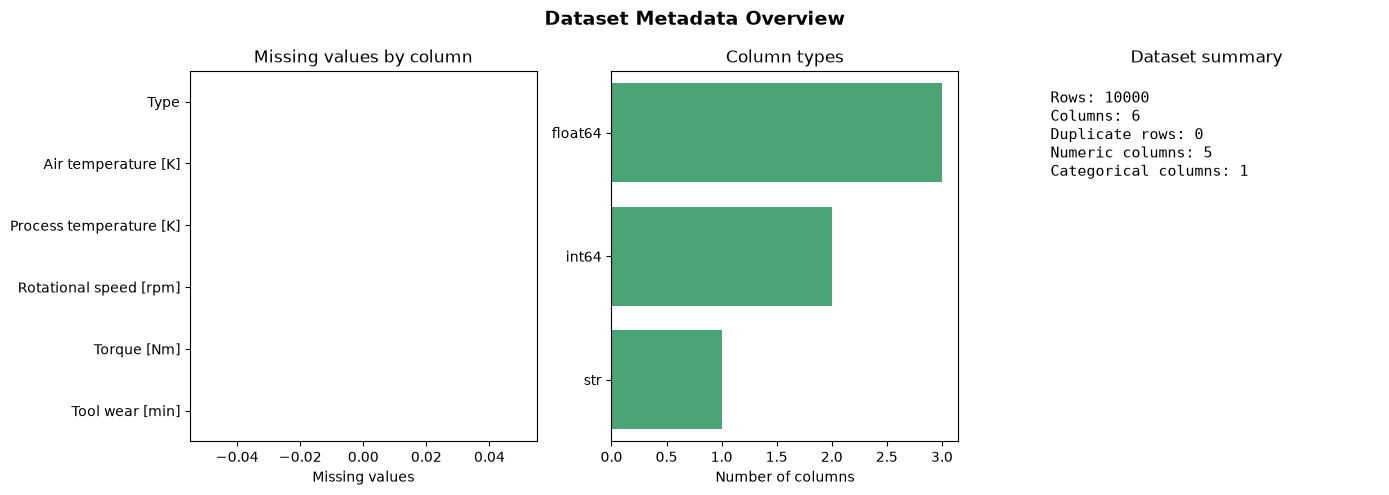

,column,dtype,missing_values,unique_values
0,Type,str,0,3
1,Air temperature [K],float64,0,93
2,Process temperature [K],float64,0,82
3,Rotational speed [rpm],int64,0,941
4,Torque [Nm],float64,0,577


In [2]:
###############################################
# Cell 2: Dataset metadata overview
###############################################

# check for missing values and data types

metadata, fig = plot_dataset_metadata_overview(data)
metadata.head()

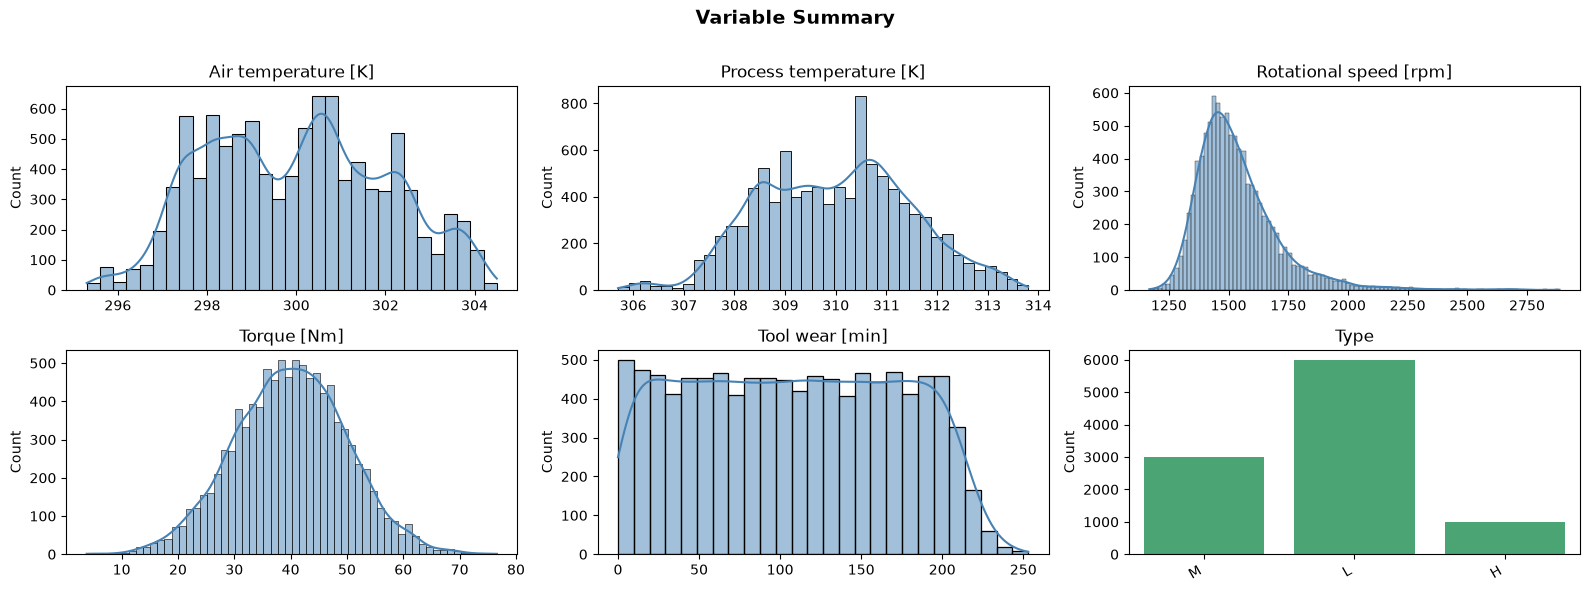

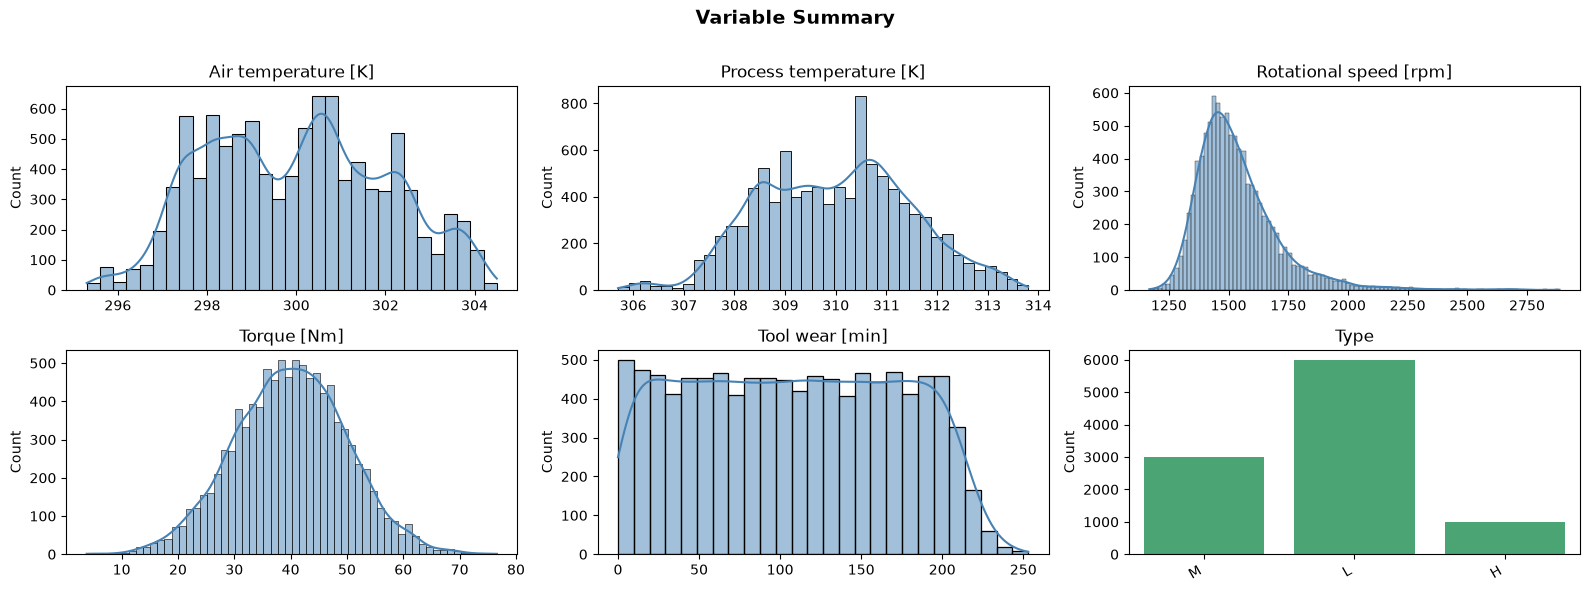

In [3]:
# Cell 3: Variable summary for presentation
plot_variable_summary(data, features=get_selected_features())

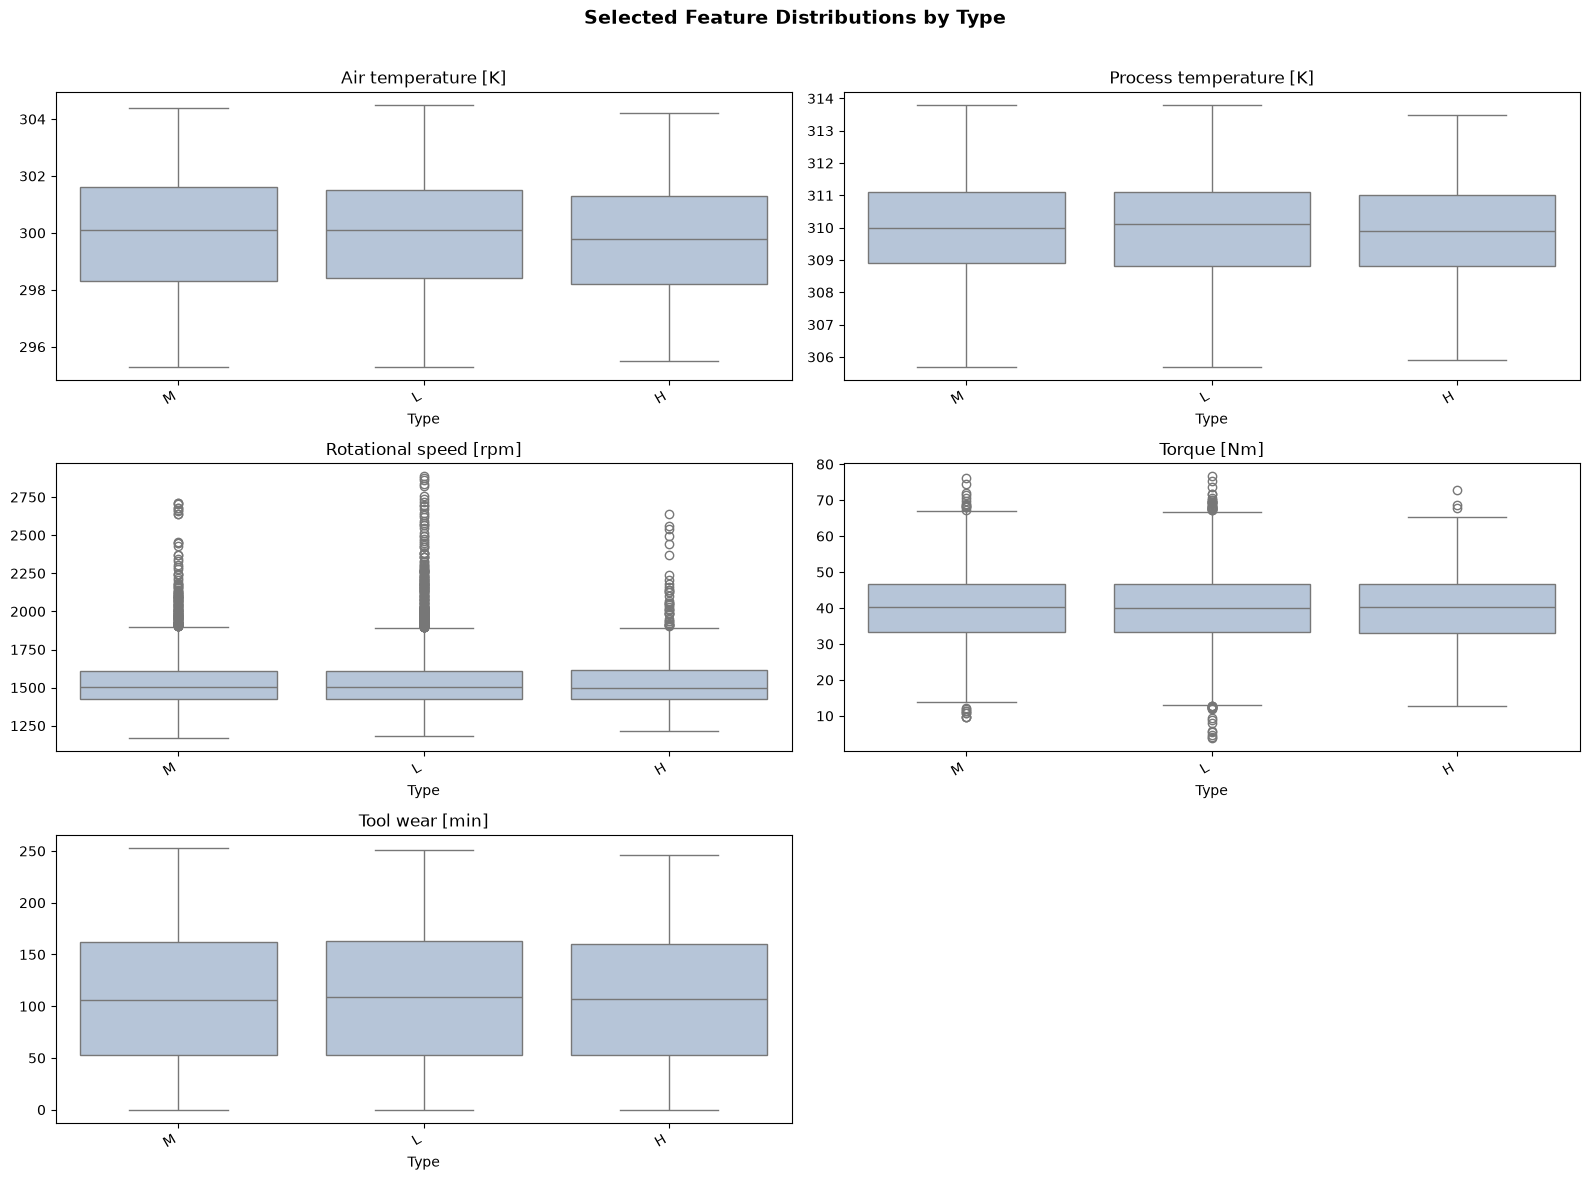

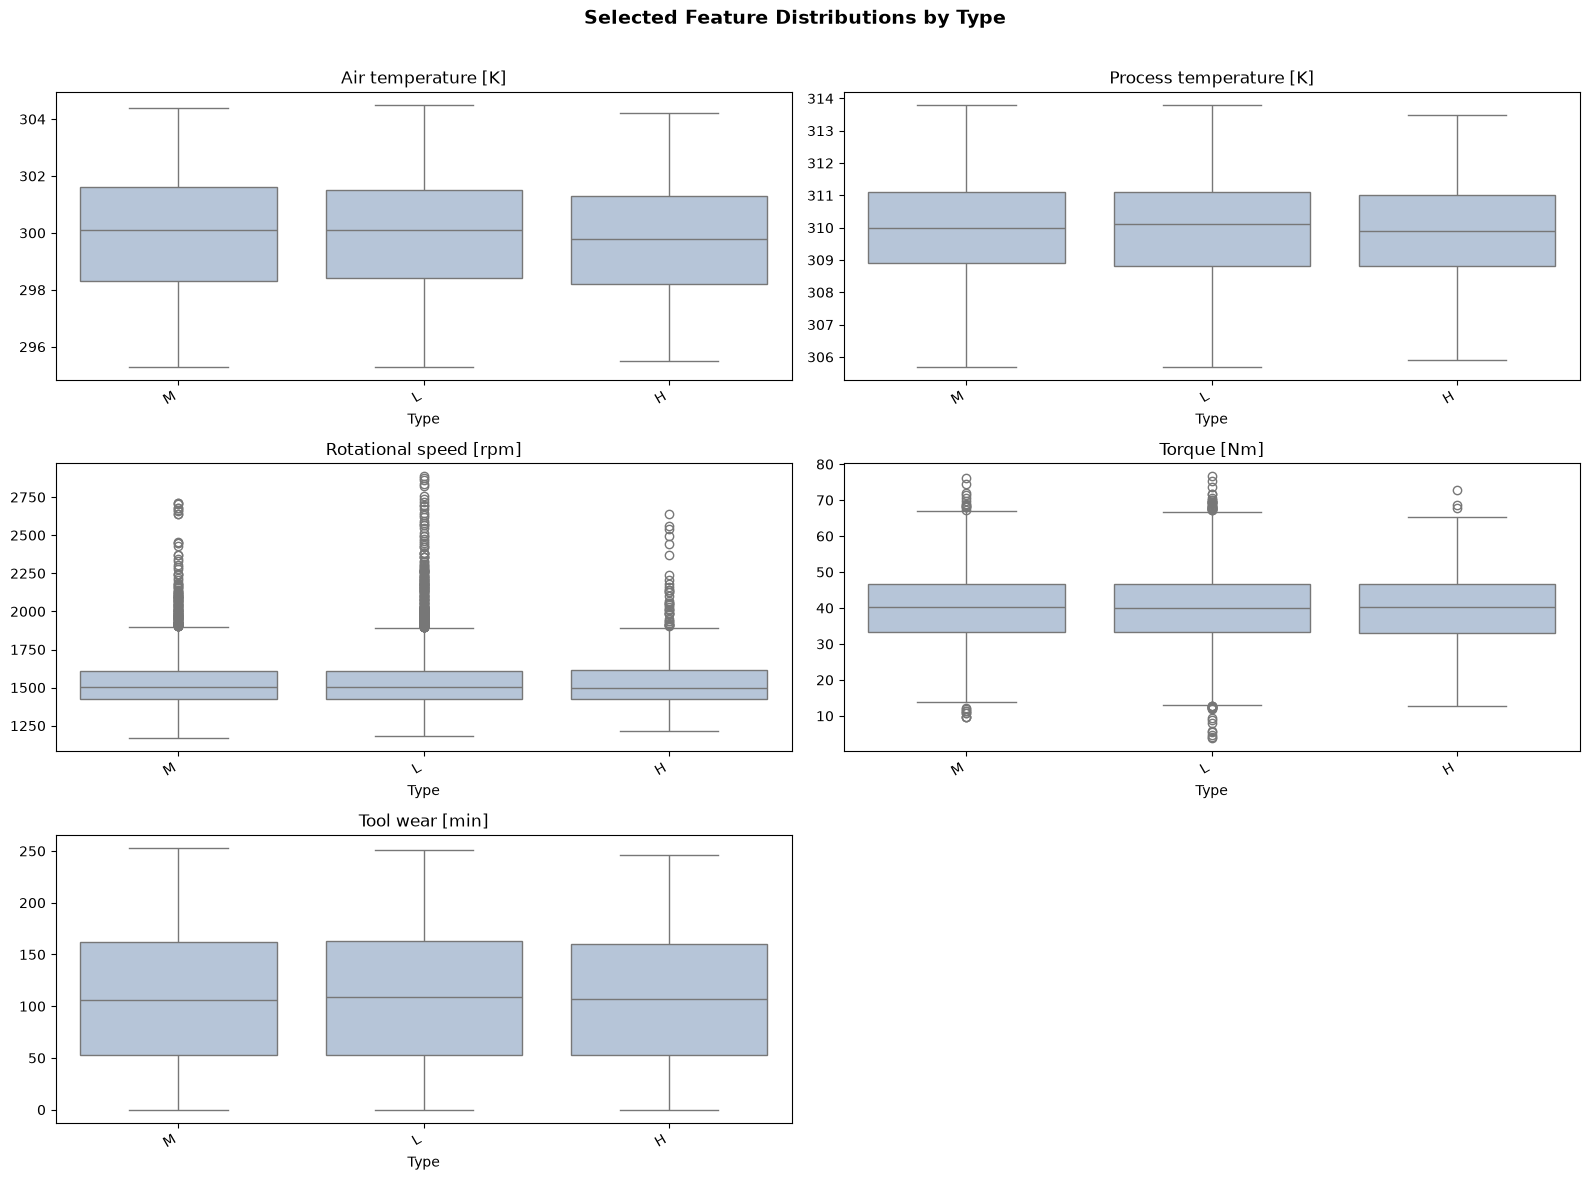

In [4]:
# Cell 4: Grouped feature distributions by Type
plot_selected_feature_distributions(data, features=get_selected_features())

Explained variance ratio: [0.35060422 0.68838537 0.87180601 0.946185   0.96936618 0.99184314
 1.        ]


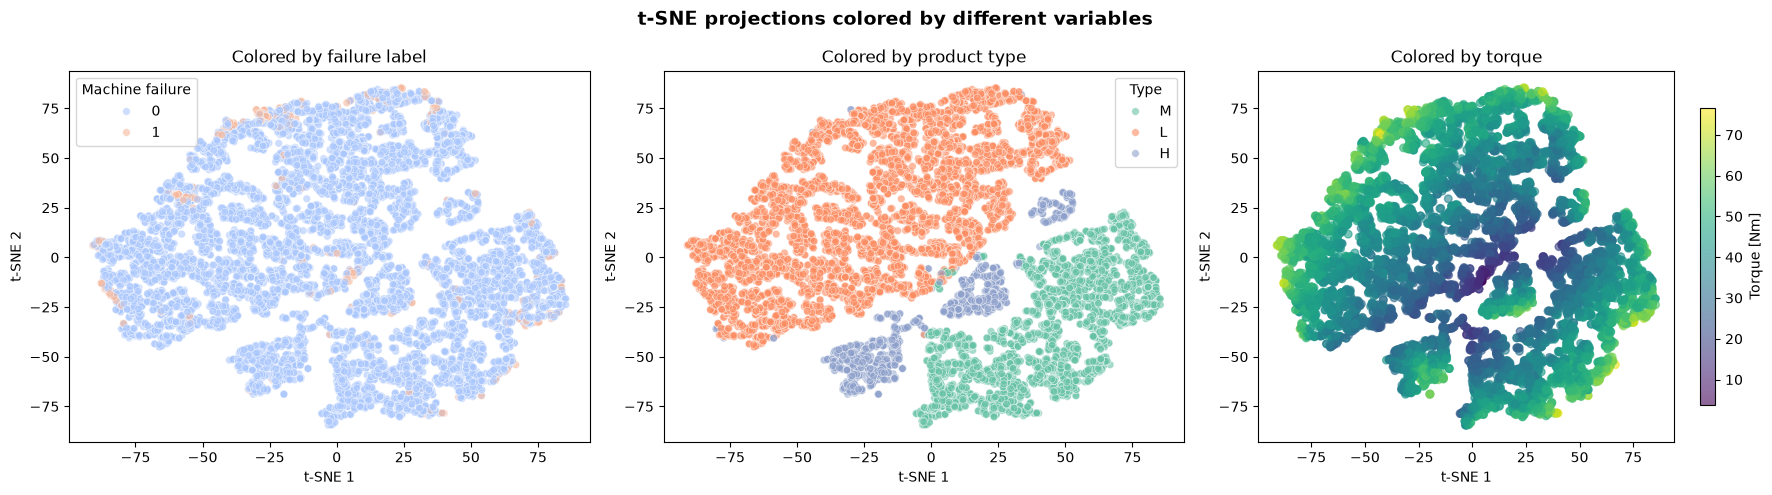

In [5]:
# Cell 4: Feature Engineering + Scaling + PCA
from src.features.build_features import create_full_pipeline, engineer_features

data_eng = engineer_features(data)
pipeline = create_full_pipeline(n_components=7)  # keep most variance
X_preprocessed = pipeline.fit_transform(data_eng)  # data_eng now contains derived features

print("Explained variance ratio:", pipeline.named_steps['pca'].explained_variance_ratio_.cumsum())

# Visualization (t-SNE / UMAP for 2D)
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_preprocessed)

tsne_df = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])
tsne_df["failure_label"] = labels["Machine failure"].astype(int)
tsne_df["product_type"] = data["Type"]
tsne_df["torque"] = data["Torque [Nm]"]
tsne_df["rotational_speed"] = data["Rotational speed [rpm]"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("t-SNE projections colored by different variables", fontsize=14, fontweight="bold")

sns.scatterplot(
    data=tsne_df,
    x="tsne_1",
    y="tsne_2",
    hue="failure_label",
    palette="coolwarm",
    alpha=0.6,
    ax=axes[0],
    s=30,
)
axes[0].set_title("Colored by failure label")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title="Machine failure")

sns.scatterplot(
    data=tsne_df,
    x="tsne_1",
    y="tsne_2",
    hue="product_type",
    palette="Set2",
    alpha=0.6,
    ax=axes[1],
    s=30,
)
axes[1].set_title("Colored by product type")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title="Type")

scatter = axes[2].scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    c=tsne_df["torque"],
    cmap="viridis",
    alpha=0.6,
    s=30,
)
axes[2].set_title("Colored by torque")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
colorbar = plt.colorbar(scatter, ax=axes[2], shrink=0.8)
colorbar.set_label("Torque [Nm]")

plt.tight_layout()
plt.show()

In [6]:
# Cell 5: Feature Selection (Correlation Filter Example)
numeric_data = data_eng.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("Highly correlated to drop:", to_drop)
print("Correlation analysis used numeric columns only.")

Highly correlated to drop: ['Process temperature [K]', 'Torque [Nm]', 'power_proxy', 'wear_rate_proxy']
Correlation analysis used numeric columns only.
